# Import and inspect data

In [90]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize, FreqDist
import string

In [91]:
df = pd.read_csv('../data/complaints.csv')

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 475518 entries, 0 to 475517
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Date received                 475518 non-null  str    
 1   Product                       475518 non-null  str    
 2   Sub-product                   475497 non-null  str    
 3   Issue                         475518 non-null  str    
 4   Sub-issue                     433216 non-null  str    
 5   Consumer complaint narrative  186441 non-null  str    
 6   Company public response       264063 non-null  str    
 7   Company                       475518 non-null  str    
 8   State                         467307 non-null  str    
 9   ZIP code                      468657 non-null  str    
 10  Tags                          45787 non-null   str    
 11  Consumer consent provided?    427408 non-null  str    
 12  Submitted via                 475518 non-null  str    


In [93]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,07/06/20,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,07/06/20,Closed with explanation,Yes,NaN,3730948
1,05/08/20,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,These are not my accounts.,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,NV,89030,NaN,Consent provided,Web,05/08/20,Closed with explanation,Yes,NaN,3642453
2,03/19/20,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,"I wrote three requests, the unverified account...",NaN,"EQUIFAX, INC.",NC,28562,NaN,Consent provided,Web,03/19/20,Closed with explanation,Yes,NaN,3573294
3,05/18/20,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,IN,46383,NaN,NaN,Phone,05/18/20,Closed with explanation,Yes,NaN,3656557
4,03/17/20,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,I was recently going to check out a new car at...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AR,72211,NaN,Consent provided,Web,03/17/20,Closed with explanation,Yes,NaN,3569824


### Isolate relevant columns

In [94]:
df = df[['Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative']]

In [95]:
df = df.rename(columns={"Product": "product", "Sub-product": "subproduct", "Issue": "issue", "Sub-issue": "subissue", "Consumer complaint narrative": "narrative"})

In [96]:
df['product'].value_counts()

product
Credit reporting, credit repair services, or other personal consumer reports    305254
Debt collection                                                                  57794
Credit card or prepaid card                                                      35196
Mortgage                                                                         26033
Checking or savings account                                                      25694
Money transfer, virtual currency, or money service                                9971
Vehicle loan or lease                                                             7444
Payday loan, title loan, or personal loan                                         4128
Student loan                                                                      4004
Name: count, dtype: int64

In [97]:
df['subproduct'].value_counts()

subproduct
Credit reporting                              302943
General-purpose credit card or charge card     24505
Checking account                               20505
Conventional home mortgage                     16960
Credit card debt                               15082
Other debt                                     15065
I do not know                                  13484
Medical debt                                    8635
Loan                                            6188
Store credit card                               4506
Government benefit card                         4211
Mobile or digital wallet                        4095
FHA mortgage                                    3717
Other banking product or service                2735
Domestic (US) money transfer                    2641
Federal student loan servicing                  2571
Auto debt                                       2170
VA mortgage                                     2018
Savings account                    

In [98]:
df['issue'].value_counts()

issue
Incorrect information on your report                                                207248
Problem with a credit reporting company's investigation into an existing problem     78527
Attempts to collect debt not owed                                                    30967
Improper use of your report                                                          17101
Managing an account                                                                  16231
                                                                                     ...  
Was approved for a loan, but didn't receive money                                        7
Vehicle was damaged or destroyed the vehicle                                             6
Property was damaged or destroyed property                                               3
Problem with an overdraft                                                                1
Property was sold                                                                   

In [99]:
df['subissue'].value_counts()

subissue
Information belongs to someone else                                                 149471
Their investigation did not fix an error on your report                              31652
Investigation took more than 30 days                                                 24697
Account status incorrect                                                             18938
Account information incorrect                                                        17794
                                                                                     ...  
Threatened to turn you in to immigration or deport you                                   6
Qualified for a better loan than the one offered                                         4
Problem with a credit reporting company's investigation into an existing problem         2
Credit monitoring or identity theft protection services                                  1
Improper use of your report                                                      

Except for 'product', it doesn't seem there's enough data to train on. Maybe I could do subproduct, too, but I'd want to eliminate those with the lower value counts.

Note for subproduct, a high number is "I don't know." I could maybe classify those. 

In 'subissue', the second highest is 'None'. Also, there seems to be a lot of overlap between the categories, finer points that some consumers may not make. Example: "Debt is not yours" vs. "Debt was result of identity theft".

# Prepare Text

## Inspect first row

In [100]:
df['narrative'].head(5)

0                                                  NaN
1                           These are not my accounts.
2    I wrote three requests, the unverified account...
3                                                  NaN
4    I was recently going to check out a new car at...
Name: narrative, dtype: str

In [101]:
print(df.iloc[0])
text = df['narrative'][2]
text

product       Credit reporting, credit repair services, or o...
subproduct                                     Credit reporting
issue                      Incorrect information on your report
subissue                    Information belongs to someone else
narrative                                                   NaN
Name: 0, dtype: str


'I wrote three requests, the unverified accounts listed below still remain on my credit report in violation of Federal Law. Equifax is under FCRA law to obtain the of the original creditors documentation on file to verify that this information is mine and is correct. I have already filed a FTC Report and Police Report. Who verified these accounts? You have NOT provided me a copy of ANY original documentation ( a consumer contract with my signature on it ) as required under Section 609 ( a ) ( 1 ) ( A ) & Section 611 ( a ) ( 1 ) ( A ). Furthermore you have failed to provide the method of verification as required under Section 611 ( a ) ( 7 ). Please be advised that under Section 611 ( 5 ) ( A ) of the FCRA you are required to promptly DELETE all information which can not be verified. \nThe law is very clear as to the Civil liability and the remedy available to me ( Section 616 & 617 ) if you fail to comply with Federal Law. I am a litigious consumer and fully intend on pursuing litigati

## Process Data

### Function to tokenize data and remove stopwords

In [102]:
stopwords_list = stopwords.words('english') + list(string.punctuation)
stopwords_list += ["''", '""', '...', '``']

In [103]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [104]:
list(string.punctuation)

['!',
 '"',
 '#',
 '$',
 '%',
 '&',
 "'",
 '(',
 ')',
 '*',
 '+',
 ',',
 '-',
 '.',
 '/',
 ':',
 ';',
 '<',
 '=',
 '>',
 '?',
 '@',
 '[',
 '\\',
 ']',
 '^',
 '_',
 '`',
 '{',
 '|',
 '}',
 '~']

In [105]:
list('abc')

['a', 'b', 'c']

In [106]:
def process_narrative(narrative):
    tokens = nltk.word_tokenize(narrative)
    stopwords_removed = [token.lower() for token in tokens if token.lower() not in stopwords_list]
    return stopwords_removed  

### Inspect and process first narrative 

In [107]:
text_words = process_narrative(text)
text_words[0:10]

['wrote',
 'three',
 'requests',
 'unverified',
 'accounts',
 'listed',
 'still',
 'remain',
 'credit',
 'report']

In [108]:
# Add to stopwords list

stopwords_list += ['--', 'xxxx']

In [109]:
# Check out word counts

text_words = process_narrative(text)

word_counts = {}
for i in range(len(text_words)):
    word_counts[text_words[i]] = text_words.count(text_words[i])
word_counts

{'wrote': 1,
 'three': 1,
 'requests': 1,
 'unverified': 1,
 'accounts': 3,
 'listed': 1,
 'still': 1,
 'remain': 1,
 'credit': 1,
 'report': 3,
 'violation': 1,
 'federal': 2,
 'law': 4,
 'equifax': 1,
 'fcra': 3,
 'obtain': 1,
 'original': 2,
 'creditors': 1,
 'documentation': 2,
 'file': 1,
 'verify': 1,
 'information': 2,
 'mine': 1,
 'correct': 1,
 'already': 1,
 'filed': 1,
 'ftc': 1,
 'police': 1,
 'verified': 2,
 'provided': 1,
 'copy': 1,
 'consumer': 2,
 'contract': 1,
 'signature': 1,
 'required': 3,
 'section': 5,
 '609': 1,
 '1': 2,
 '611': 3,
 'furthermore': 1,
 'failed': 1,
 'provide': 1,
 'method': 1,
 'verification': 1,
 '7': 1,
 'please': 2,
 'advised': 1,
 '5': 1,
 'promptly': 1,
 'delete': 1,
 'clear': 1,
 'civil': 1,
 'liability': 1,
 'remedy': 1,
 'available': 1,
 '616': 1,
 '617': 1,
 'fail': 1,
 'comply': 1,
 'litigious': 1,
 'fully': 1,
 'intend': 1,
 'pursuing': 1,
 'litigation': 1,
 'matter': 1,
 'enforce': 1,
 'rights': 1,
 'remove': 1,
 'following': 1}

It seems there are a lot of numbers. Update function to get rid of numbers from the list.  

Note: this function also gets rid of strings with punctuation in it like 'xx/xx/xxxx' or "n't".

In [110]:
def process_narrative(narrative):
    tokens = nltk.word_tokenize(narrative)
    stopwords_removed = [token.lower() for token in tokens if token.lower() not in stopwords_list]
    
    # adding line to remove all tokens with numbers and punctuation
    stopwords_punc_and_numbers_removed = [word for word in stopwords_removed if word.isalpha()]
    
    return stopwords_punc_and_numbers_removed  

In [111]:
# Redoing processing with updated function
text_words = process_narrative(text)

### Make dictionary of word counts

In [112]:
FreqDist(text_words)

FreqDist({'section': 5, 'law': 4, 'accounts': 3, 'report': 3, 'fcra': 3, 'required': 3, 'federal': 2, 'original': 2, 'documentation': 2, 'information': 2, ...})

In [113]:
type(FreqDist(text_words))

nltk.probability.FreqDist

In [114]:
FreqDist(text_words).most_common(10)

[('section', 5),
 ('law', 4),
 ('accounts', 3),
 ('report', 3),
 ('fcra', 3),
 ('required', 3),
 ('federal', 2),
 ('original', 2),
 ('documentation', 2),
 ('information', 2)]

Note how calling `most_common()` creates a list of tuples.

<Axes: xlabel='Samples', ylabel='Counts'>

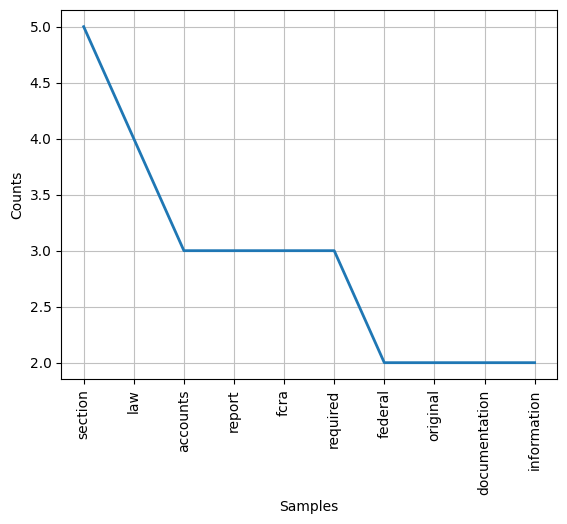

In [115]:
FreqDist(text_words).plot(10)

### Trying process on the next two rows

#### df.iloc[1]

In [116]:
df.iloc[5][0:5]

product                                            Student loan
subproduct                       Federal student loan servicing
issue                      Dealing with your lender or servicer
subissue                     Keep getting calls about your loan
narrative     They call at all hours and on the weekends usi...
Name: 5, dtype: str

In [117]:
text = df['narrative'][5]
text

'They call at all hours and on the weekends using various numbers.'

In [118]:
text_words = process_narrative(text)

In [119]:
FreqDist(text_words).most_common(30)

[('call', 1),
 ('hours', 1),
 ('weekends', 1),
 ('using', 1),
 ('various', 1),
 ('numbers', 1)]

#### df.iloc[2]

In [120]:
df.iloc[8][0:5]

product       Credit reporting, credit repair services, or o...
subproduct                                     Credit reporting
issue         Problem with a credit reporting company's inve...
subissue      Their investigation did not fix an error on yo...
narrative     I notified Experian of an inaccuracy on my rep...
Name: 8, dtype: str

In [121]:
text = df['narrative'][8]
text_words = process_narrative(text)
FreqDist(text_words).most_common(30)

[('experian', 3),
 ('report', 2),
 ('credit', 2),
 ('another', 2),
 ('deleted', 2),
 ('info', 2),
 ('remain', 2),
 ('notified', 1),
 ('inaccuracy', 1),
 ('national', 1),
 ('adjust', 1),
 ('account', 1),
 ('reported', 1),
 ('company', 1),
 ('proven', 1),
 ('invalid', 1),
 ('created', 1),
 ('called', 1),
 ('investigation', 1),
 ('lead', 1),
 ('collection', 1),
 ('agency', 1),
 ('previously', 1),
 ('information', 1),
 ('completely', 1),
 ('false', 1),
 ('please', 1),
 ('help', 1)]

In [122]:
df.iloc[2]

product       Credit reporting, credit repair services, or o...
subproduct                                     Credit reporting
issue                      Incorrect information on your report
subissue                    Information belongs to someone else
narrative     I wrote three requests, the unverified account...
Name: 2, dtype: str

# Combine categories and create new dataframes

## Inspect 

In [123]:
# Inspect products again
df['product'].value_counts()

product
Credit reporting, credit repair services, or other personal consumer reports    305254
Debt collection                                                                  57794
Credit card or prepaid card                                                      35196
Mortgage                                                                         26033
Checking or savings account                                                      25694
Money transfer, virtual currency, or money service                                9971
Vehicle loan or lease                                                             7444
Payday loan, title loan, or personal loan                                         4128
Student loan                                                                      4004
Name: count, dtype: int64

What is "Money transfer, virtual currency, or money service"?

In [124]:
df[df['product'] == "Money transfer, virtual currency, or money service"].head(10)

,product,subproduct,issue,subissue,narrative
72,"Money transfer, virtual currency, or money ser...",International money transfer,Fraud or scam,NaN,NaN
123,"Money transfer, virtual currency, or money ser...",Virtual currency,Other transaction problem,NaN,Someone sent me {$25.00} on XX/XX/XXXX through...
164,"Money transfer, virtual currency, or money ser...",Mobile or digital wallet,Fraud or scam,NaN,NaN
217,"Money transfer, virtual currency, or money ser...",Mobile or digital wallet,Problem adding money,NaN,I am trying to link my PNC checking account wi...
253,"Money transfer, virtual currency, or money ser...",Domestic (US) money transfer,Other service problem,NaN,I received my direct deposit to my bmo account...
272,"Money transfer, virtual currency, or money ser...",Mobile or digital wallet,Unauthorized transactions or other transaction...,NaN,PayPal -negative {$3000.00} XX/XX/2020 Transfe...
464,"Money transfer, virtual currency, or money ser...",International money transfer,Other service problem,NaN,I tried to get the company to deactivate my ac...
535,"Money transfer, virtual currency, or money ser...",International money transfer,Fraud or scam,NaN,Hi I am very overwhelmed.. I am being XXXX.. i...
546,"Money transfer, virtual currency, or money ser...",Virtual currency,Fraud or scam,NaN,Account opened XX/XX/XXXX and deposited {$1000...
646,"Money transfer, virtual currency, or money ser...",Mobile or digital wallet,"Managing, opening, or closing your mobile wall...",NaN,NaN


Seems to be about Venmo, digital transactions, international transfers, etc. It's a bit of it's own thing. I'll keep it for now, but there are only 4,602 entries. But I'll fold into "checking and savings" in general, which has only 9,000.

## Combine categories

**Tasks**

- Rename "credit_reporting"  
- Rename "debt_collection"  
- Rename "credit_card"
- Rename "mortgage"
- Combine "checking" and "money transfer" into "retail_banking"
- Combine the loans into "loans"

In [125]:
df['product'].value_counts()

product
Credit reporting, credit repair services, or other personal consumer reports    305254
Debt collection                                                                  57794
Credit card or prepaid card                                                      35196
Mortgage                                                                         26033
Checking or savings account                                                      25694
Money transfer, virtual currency, or money service                                9971
Vehicle loan or lease                                                             7444
Payday loan, title loan, or personal loan                                         4128
Student loan                                                                      4004
Name: count, dtype: int64

In [157]:
df['product'] = df['product'].astype(str).replace({'Credit reporting, credit repair services, or other personal consumer reports': 'credit_reporting',
                       'Debt collection': 'debt_collection',
                       'Credit card or prepaid card': 'credit_card',
                       'Mortgage': 'mortgage',
                       'Checking or savings account': 'retail_banking',
                       'Money transfer, virtual currency, or money service': 'retail_banking',
                       'Vehicle loan or lease': 'loans',
                       'Payday loan, title loan, or personal loan': 'loans',
                       'Student loan': 'loans'}, inplace=True)

/var/folders/5z/_v91q0bs3cl_y08k407bg0t00000gn/T/ipykernel_43538/3420717178.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['product'] = df['product'].astype(str).replace({'Credit reporting, credit repair services, or other personal consumer reports': 'credit_reporting',


In [158]:
df['product'].unique()


<ArrowStringArray>
['credit_reporting',            'loans',  'debt_collection',
   'retail_banking',      'credit_card',         'mortgage']
Length: 6, dtype: str

In [159]:
df['product'].value_counts()

product
credit_reporting    305254
debt_collection      57794
retail_banking       35665
credit_card          35196
mortgage             26033
loans                15576
Name: count, dtype: int64

Mortgage and loans are the smallest. Since they're both types of loans, I'll combine them.

In [189]:
df['product'] = df['product'].replace({'mortgage': 'mortgages_and_loans',
                       'loans': 'mortgages_and_loans'}, inplace=True)
df['product'].value_counts()

/var/folders/5z/_v91q0bs3cl_y08k407bg0t00000gn/T/ipykernel_43538/3030008019.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['product'] = df['product'].replace({'mortgage': 'mortgages_and_loans',


product
credit_reporting       305254
debt_collection         57794
mortgages_and_loans     41609
retail_banking          35665
credit_card             35196
Name: count, dtype: int64

In [190]:
df['product']

0         credit_reporting
1         credit_reporting
2         credit_reporting
3         credit_reporting
4         credit_reporting
                ...       
475513     debt_collection
475514      retail_banking
475515    credit_reporting
475516    credit_reporting
475517      retail_banking
Name: product, Length: 475518, dtype: str

## Create new dataframes

In [191]:
credit_reporting_df = df[df['product'] == 'credit_reporting']
debt_collection_df = df[df['product'] == 'debt_collection']
mortgages_and_loans_df = df[df['product'] == 'mortgages_and_loans']
credit_card_df = df[df['product'] == 'credit_card']
retail_banking_df = df[df['product'] == 'retail_banking']

## Concatenate all the narratives into a single string per class

In [192]:
credit_reporting_df.head()

,product,subproduct,issue,subissue,narrative
0,credit_reporting,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN
1,credit_reporting,Credit reporting,Incorrect information on your report,Information belongs to someone else,These are not my accounts.
2,credit_reporting,Credit reporting,Incorrect information on your report,Information belongs to someone else,"I wrote three requests, the unverified account..."
3,credit_reporting,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN
4,credit_reporting,Credit reporting,Incorrect information on your report,Information belongs to someone else,I was recently going to check out a new car at...


In [193]:
mortgages_and_loans_df.head()

,product,subproduct,issue,subissue,narrative
5,mortgages_and_loans,Federal student loan servicing,Dealing with your lender or servicer,Keep getting calls about your loan,They call at all hours and on the weekends usi...
19,mortgages_and_loans,Home equity loan or line of credit (HELOC),Trouble during payment process,NaN,"This complaint is for TCF, Identical complaint..."
24,mortgages_and_loans,Conventional home mortgage,Struggling to pay mortgage,NaN,Rushmore Loan management XXXX will not permit ...
28,mortgages_and_loans,FHA mortgage,Applying for a mortgage or refinancing an exis...,NaN,NaN
30,mortgages_and_loans,FHA mortgage,Trouble during payment process,NaN,"I currently have my mortgage with GMFS, servic..."


In [166]:
def concat_narratives(df):
    # concat narratives, drop NaN values
    narr = ''.join(df['narrative'].dropna().astype(str))
    print('Finished Concatenation')
    return narr

In [167]:
credit_reporting_text = concat_narratives(credit_reporting_df)
credit_reporting_text_processed = process_narrative(credit_reporting_text)

Finished Concatenation


In [168]:
debt_collection_text = concat_narratives(debt_collection_df)
debt_collection_text_processed = process_narrative(debt_collection_text)

Finished Concatenation


In [194]:
mortgages_and_loans_text = concat_narratives(mortgages_and_loans_df)
mortgages_and_loans_text_processed = process_narrative(mortgages_and_loans_text)

Finished Concatenation


In [170]:
credit_card_text = concat_narratives(credit_card_df)
credit_card_text_processed = process_narrative(credit_card_text)

Finished Concatenation


In [171]:
retail_banking_text = concat_narratives(retail_banking_df)
retail_banking_text_processed = process_narrative(retail_banking_text)

Finished Concatenation


### Saving the text files

In [172]:
text_file = open('../data/credit_reporting_text.txt', 'w')
text_file.write(credit_reporting_text)
text_file.close()

In [173]:
text_file = open('../data/debt_collection_text.txt', 'w')
text_file.write(debt_collection_text)
text_file.close()

In [196]:
text_file = open('../data/mortgages_and_loans_text.txt', 'w')
mortgages_and_loans_text = mortgages_and_loans_text.replace('\x82', '')
text_file.write(mortgages_and_loans_text)
text_file.close()

In [175]:
text_file = open('../data/credit_card_text.txt', 'w')
text_file.write(credit_card_text)
text_file.close()

In [176]:
text_file = open('../data/retail_banking_text.txt', 'w')
text_file.write(retail_banking_text)
text_file.close()

### Saving the processed text (lists) files

In [177]:
temp = pd.DataFrame(credit_reporting_text_processed)
temp.to_csv('../data/credit_reporting_text_processed.csv')

In [178]:
temp = pd.DataFrame(debt_collection_text_processed)
temp.to_csv('../data/debt_collection_text_processed.csv')

In [197]:
temp = pd.DataFrame(mortgages_and_loans_text_processed)
temp.to_csv('../data/mortgages_and_loans_text_processed.csv')

In [180]:
temp = pd.DataFrame(credit_card_text_processed)
temp.to_csv('../data/credit_card_text_processed.csv')

In [181]:
temp = pd.DataFrame(retail_banking_text_processed)
temp.to_csv('../data/retail_banking_text_processed.csv')

## Check `FreqDist()`

In [182]:
FreqDist(debt_collection_text_processed).most_common(30)

[('credit', 50156),
 ('debt', 48922),
 ('account', 35943),
 ('collection', 22983),
 ('information', 21407),
 ('report', 21381),
 ('company', 20169),
 ('reporting', 14915),
 ('received', 14060),
 ('letter', 12673),
 ('never', 12201),
 ('sent', 11677),
 ('would', 11571),
 ('consumer', 10393),
 ('payment', 10241),
 ('also', 9633),
 ('amount', 9628),
 ('agency', 9596),
 ('called', 9543),
 ('told', 9153),
 ('pay', 8963),
 ('call', 8848),
 ('provide', 8664),
 ('paid', 8530),
 ('time', 8528),
 ('number', 8194),
 ('phone', 8111),
 ('please', 7910),
 ('original', 7866),
 ('act', 7589)]

In [183]:
FreqDist(credit_reporting_text_processed).most_common(30)

[('credit', 248083),
 ('report', 136990),
 ('account', 127250),
 ('information', 115177),
 ('reporting', 87171),
 ('accounts', 75940),
 ('consumer', 49221),
 ('dispute', 38546),
 ('identity', 36421),
 ('please', 34556),
 ('days', 33696),
 ('remove', 32066),
 ('sent', 31865),
 ('also', 31819),
 ('payment', 31712),
 ('received', 31105),
 ('bureaus', 30114),
 ('file', 29654),
 ('inaccurate', 29450),
 ('never', 29275),
 ('date', 28925),
 ('theft', 28651),
 ('letter', 28645),
 ('late', 28559),
 ('debt', 28546),
 ('items', 28509),
 ('collection', 28434),
 ('reported', 28156),
 ('balance', 28055),
 ('fraudulent', 27337)]

In [184]:
FreqDist(credit_card_text_processed).most_common(30)

[('card', 39175),
 ('credit', 36833),
 ('account', 29419),
 ('bank', 15567),
 ('would', 14903),
 ('payment', 14029),
 ('one', 12555),
 ('received', 11570),
 ('told', 11564),
 ('called', 11442),
 ('time', 10112),
 ('never', 9179),
 ('balance', 9031),
 ('back', 8977),
 ('due', 8424),
 ('made', 8211),
 ('said', 8081),
 ('dispute', 8002),
 ('charge', 7877),
 ('call', 7872),
 ('get', 7855),
 ('charges', 7759),
 ('late', 7414),
 ('company', 7372),
 ('could', 7172),
 ('pay', 6818),
 ('customer', 6774),
 ('chase', 6749),
 ('information', 6594),
 ('interest', 6565)]

In [185]:
FreqDist(retail_banking_text_processed).most_common(30)

[('account', 49391),
 ('bank', 29320),
 ('money', 18920),
 ('would', 12710),
 ('told', 11519),
 ('funds', 10301),
 ('back', 9542),
 ('called', 9127),
 ('check', 9068),
 ('received', 8831),
 ('card', 8644),
 ('said', 7797),
 ('get', 7617),
 ('days', 7293),
 ('sent', 7195),
 ('paypal', 7190),
 ('time', 7093),
 ('one', 6945),
 ('could', 6706),
 ('number', 6622),
 ('call', 6542),
 ('checking', 6473),
 ('email', 6370),
 ('chase', 6202),
 ('phone', 6074),
 ('information', 6029),
 ('transaction', 5934),
 ('never', 5906),
 ('also', 5647),
 ('made', 5536)]

In [198]:
FreqDist(mortgages_and_loans_text_processed).most_common(30)

[('loan', 45487),
 ('payment', 34751),
 ('mortgage', 30346),
 ('would', 26530),
 ('account', 20675),
 ('payments', 20425),
 ('told', 18483),
 ('credit', 18095),
 ('received', 16962),
 ('company', 15469),
 ('time', 15269),
 ('called', 14392),
 ('due', 13977),
 ('bank', 13302),
 ('pay', 13026),
 ('get', 12866),
 ('back', 12717),
 ('call', 12655),
 ('paid', 12597),
 ('sent', 11844),
 ('amount', 11516),
 ('made', 10697),
 ('said', 10654),
 ('home', 10528),
 ('information', 10428),
 ('never', 10372),
 ('could', 9929),
 ('one', 9802),
 ('also', 9455),
 ('late', 9439)]